In [ ]:
import pandas as pd
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report
import re
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Đọc dữ liệu

In [ ]:
print("1. Đang đọc dữ liệu ...")
df_fake = pd.read_csv('../data/raw/Fake.csv')
df_fake['label'] = 1
df_true = pd.read_csv('../data/raw/True.csv')
df_true['label'] = 0

df = pd.concat([df_fake, df_true], ignore_index=True)
df['text'] = df['text'].str.replace(r'^.*?\(reuters\) - ', '', regex=True, flags=re.IGNORECASE)
df = df.dropna(subset=['text'])
df['text'] = df['text'].astype(str)

1. Đang đọc dữ liệu ...


### 1.5 Phân tích dữ liệu (EDA)

Đang vẽ biểu đồ phân tích...


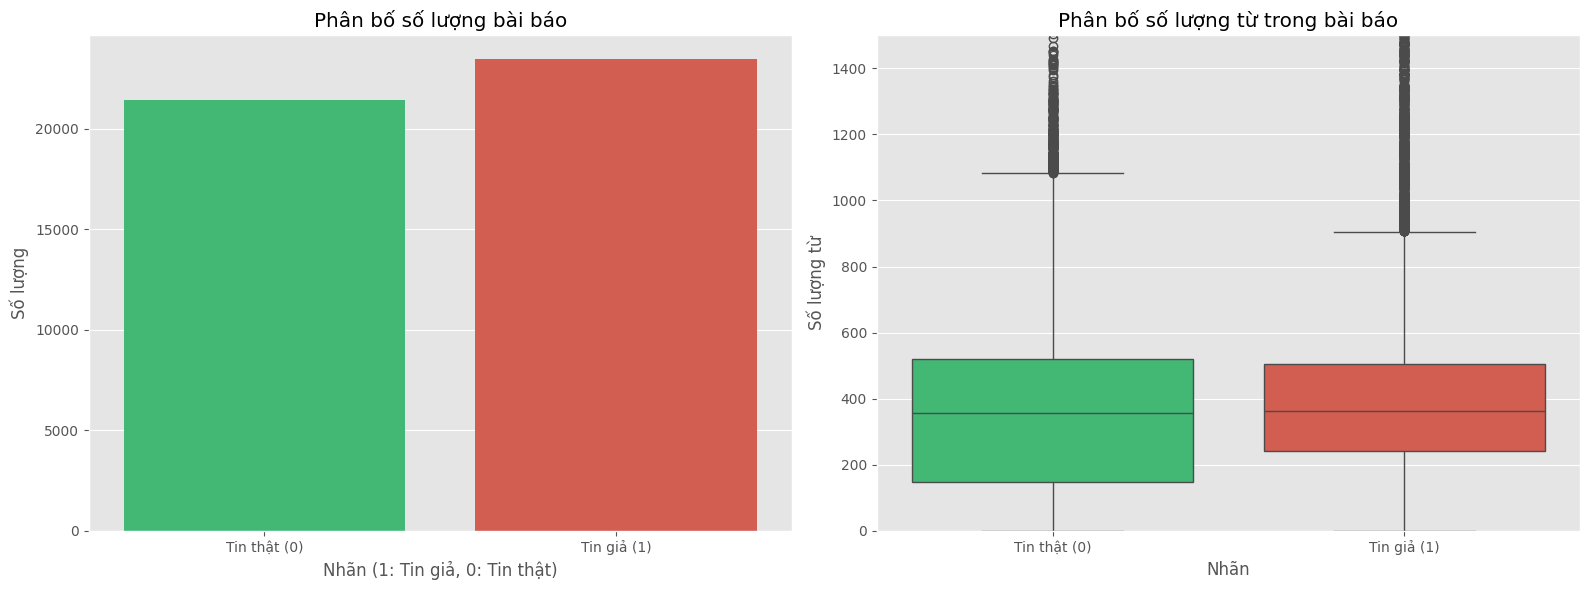

In [3]:
print("Đang vẽ biểu đồ phân tích...")
plt.style.use("ggplot")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Phân bố số lượng bài báo (Tin giả vs Tin thật)
sns.countplot(data=df, x="label", hue="label", ax=axes[0], palette=["#2ecc71", "#e74c3c"], legend=False)
axes[0].set_title("Phân bố số lượng bài báo")
axes[0].set_xlabel("Nhãn (1: Tin giả, 0: Tin thật)")
axes[0].set_ylabel("Số lượng")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Tin thật (0)", "Tin giả (1)"])

# Tính số lượng từ trong mỗi bài báo cho biểu đồ 2
df["word_count"] = df["text"].apply(lambda x: len(str(x).split()))

# Biểu đồ 2: Phân bố số lượng từ trung bình trong văn bản
sns.boxplot(data=df, x="label", y="word_count", hue="label", ax=axes[1], palette=["#2ecc71", "#e74c3c"], legend=False)
axes[1].set_title("Phân bố số lượng từ trong bài báo")
axes[1].set_xlabel("Nhãn")
axes[1].set_ylabel("Số lượng từ")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Tin thật (0)", "Tin giả (1)"])
axes[1].set_ylim(0, 1500) # Giới hạn trục Y để dễ nhìn hơn

plt.tight_layout()
plt.show()

### 2 Tiền xử lý văn bản

In [4]:
print("Đang tiền xử lý văn bản ...")
stemmer = PorterStemmer()

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    # Stemming (rút gọn từ về gốc)
    text = ' '.join([stemmer.stem(word) for word in text.split()])
    return text


Đang tiền xử lý văn bản ...


In [ ]:
df['clean_text'] = df['text'].apply(preprocess_text)
df.to_csv('../data/processed/processed_data.csv', index=False)

### 3. Chia tập dữ liệu và trích xuất đặc trưng

In [6]:
print("Đang chia tập dữ liệu và trích xuất đặc trưng...")
x = df['clean_text']
y = df['label']

# Chia dữ liệu: 80% để train, 20% để test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Đang chia tập dữ liệu và trích xuất đặc trưng...


In [7]:
# Sử dụng TF-IDF để chuyển đổi văn bản thành ma trận các con số
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1, 2)) # Lấy 5000 từ quan trọng nhất
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

### 4. Huấn luyện với mô hình Logistic Regression

In [8]:
from sklearn.linear_model import LogisticRegression

print("Đang huấn luyện mô hình Logistic Regression ...")
LR = LogisticRegression()
LR.fit(x_train_tfidf, y_train)

pred_LR = LR.predict(x_test_tfidf)
print("\n=== KẾT QUẢ ĐÁNH GIÁ ===")
print(f"Độ chính xác (Accuracy): {accuracy_score(y_test, pred_LR) * 100:.2f}%")
print(classification_report(y_test, pred_LR, target_names=["Tin thật (0)", "Tin giả (1)"]))

Đang huấn luyện mô hình Logistic Regression ...

=== KẾT QUẢ ĐÁNH GIÁ ===
Độ chính xác (Accuracy): 98.16%
              precision    recall  f1-score   support

Tin thật (0)       0.98      0.98      0.98      4247
 Tin giả (1)       0.98      0.98      0.98      4733

    accuracy                           0.98      8980
   macro avg       0.98      0.98      0.98      8980
weighted avg       0.98      0.98      0.98      8980



### 5. Huấn luyện với mô hình Decision Tree


In [9]:
from sklearn.tree import DecisionTreeClassifier

print("Đang huấn luyện mô hình Decision Tree...")
DT = DecisionTreeClassifier()
DT.fit(x_train_tfidf, y_train)

pred_DT = DT.predict(x_test_tfidf)
print("\n=== KẾT QUẢ DECISION TREE ===")
print(f"Độ chính xác: {accuracy_score(y_test, pred_DT) * 100:.2f}%")
print(classification_report(y_test, pred_DT, target_names=["Tin thật (0)", "Tin giả (1)"]))


Đang huấn luyện mô hình Decision Tree...

=== KẾT QUẢ DECISION TREE ===
Độ chính xác: 95.00%
              precision    recall  f1-score   support

Tin thật (0)       0.96      0.94      0.95      4247
 Tin giả (1)       0.94      0.96      0.95      4733

    accuracy                           0.95      8980
   macro avg       0.95      0.95      0.95      8980
weighted avg       0.95      0.95      0.95      8980



### 6. Huấn luyện với mô hình Random Forest


In [10]:
from sklearn.ensemble import RandomForestClassifier

print("Đang huấn luyện mô hình Random Forest...")
RF = RandomForestClassifier(random_state=0)
RF.fit(x_train_tfidf, y_train)

pred_RF = RF.predict(x_test_tfidf)
print("\n=== KẾT QUẢ RANDOM FOREST ===")
print(f"Độ chính xác: {accuracy_score(y_test, pred_RF) * 100:.2f}%")
print(classification_report(y_test, pred_RF, target_names=["Tin thật (0)", "Tin giả (1)"]))


Đang huấn luyện mô hình Random Forest...

=== KẾT QUẢ RANDOM FOREST ===
Độ chính xác: 98.78%
              precision    recall  f1-score   support

Tin thật (0)       0.99      0.99      0.99      4247
 Tin giả (1)       0.99      0.99      0.99      4733

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



### 7. Huấn luyện với mô hình Naive Bayes


In [11]:
from sklearn.naive_bayes import MultinomialNB

print("Đang huấn luyện mô hình Naive Bayes...")
NB = MultinomialNB()
NB.fit(x_train_tfidf, y_train)

pred_NB = NB.predict(x_test_tfidf)
print("\n=== KẾT QUẢ NAIVE BAYES ===")
print(f"Độ chính xác: {accuracy_score(y_test, pred_NB) * 100:.2f}%")
print(classification_report(y_test, pred_NB, target_names=["Tin thật (0)", "Tin giả (1)"]))


Đang huấn luyện mô hình Naive Bayes...

=== KẾT QUẢ NAIVE BAYES ===
Độ chính xác: 93.57%
              precision    recall  f1-score   support

Tin thật (0)       0.94      0.93      0.93      4247
 Tin giả (1)       0.93      0.94      0.94      4733

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



### 8. Huấn luyện với mô hình Support Vector Machine (SVM)


In [ ]:
from sklearn.svm import SVC

print("Đang huấn luyện mô hình SVM (có thể mất vài phút)...")
# Khởi tạo SVM với kernel='linear' và bật probability=True để tính xác suất
SVM = SVC(kernel='linear', probability=True, random_state=0)
SVM.fit(x_train_tfidf, y_train)

pred_SVM = SVM.predict(x_test_tfidf)
print("\n=== KẾT QUẢ SVM ===")
print(f"Độ chính xác: {accuracy_score(y_test, pred_SVM) * 100:.2f}%")
print(classification_report(y_test, pred_SVM, target_names=["Tin thật (0)", "Tin giả (1)"]))


Đang huấn luyện mô hình SVM (có thể mất vài phút)...


In [ ]:
# --- THỬ NGHIỆM THỰC TẾ VỚI GIAO DIỆN ---
import ipywidgets as widgets
from IPython.display import display

# Tạo giao diện nhập liệu
text_area = widgets.Textarea(
    value='',
    placeholder='Dán nội dung bài báo tiếng Anh vào đây...',
    description='Bài báo:',
    disabled=False,
    layout=widgets.Layout(width='100%', height='150px')
)
button = widgets.Button(description="Dự đoán", button_style='success')
output = widgets.Output()

display(text_area, button, output)

def on_button_clicked(b):
    with output:
        output.clear_output()
        news_text = text_area.value
        if not news_text.strip():
            print("Vui lòng nhập nội dung bài báo.")
            return
        
        # Tiền xử lý và vector hóa
        news_cleaned = preprocess_text(news_text)
        news_tfidf = vectorizer.transform([news_cleaned])
        
        models = {
            'Logistic Regression': LR,
            'Decision Tree': DT,
            'Random Forest': RF,
            'Naive Bayes': NB,
            'SVM': SVM
        }
        
        print(f"{'='*50}")
        print("KẾT QUẢ DỰ ĐOÁN TỪ CÁC MÔ HÌNH:")
        print(f"{'='*50}")
        for name, model in models.items():
            res = model.predict(news_tfidf)[0]
            prob = model.predict_proba(news_tfidf)[0]
            max_prob = max(prob) * 100
            label_str = "Tin giả 🛑" if res == 1 else "Tin thật ✅"
            print(f"- {name:<20}: {label_str:<12} (Xác suất: {max_prob:.2f}%)")
        print(f"{'='*50}")

button.on_click(on_button_clicked)


Textarea(value='', description='Bài báo:', layout=Layout(height='150px', width='100%'), placeholder='Dán nội d…

Button(button_style='success', description='Dự đoán', style=ButtonStyle())

Output()